In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

In [2]:
experiment_A = pd.read_csv("./experiment-A-27.csv")
vals_A = ["initial-population","step","population","get-market-utilization","gini-index","mean-vision","mean-metabolism"]
experiment_A = experiment_A[vals_A]
experiment_A 

,initial-population,step,population,get-market-utilization,gini-index,mean-vision,mean-metabolism
0,10,0,10,0.918318,0.192216,2.900000,1.900000
1,10,0,10,1.304978,0.214286,3.400000,2.700000
2,10,0,10,1.111648,0.266412,3.700000,2.300000
3,10,0,10,1.304978,0.214286,3.600000,2.700000
4,10,1,10,1.111648,0.275940,3.700000,2.300000
...,...,...,...,...,...,...,...
240475,2499,496,769,46.640889,0.348732,3.927178,1.254876
240476,2499,497,769,46.640889,0.348729,3.927178,1.254876
240477,2499,498,769,46.640889,0.348728,3.927178,1.254876
240478,2499,499,769,46.640889,0.348749,3.927178,1.254876


In [3]:
experiment_A_summary = experiment_A.groupby(['initial-population', 'step']).agg(['mean', 'std'])
experiment_A_summary.columns = [f"{col[0]}_{col[1]}" for col in experiment_A_summary.columns.values]


experiment_A_summary = experiment_A_summary.reset_index()


experiment_A_summary


#experiment_A_summary.to_csv("experiment_A_processed.csv", index=False)

,initial-population,step,population_mean,population_std,get-market-utilization_mean,get-market-utilization_std,gini-index_mean,gini-index_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
0,10,0,10.000000,0.000000,1.197036,0.168715,0.225439,0.037690,3.513333,0.500850,2.476667,0.349071
1,10,1,10.000000,0.000000,1.197036,0.168715,0.232876,0.044231,3.513333,0.500850,2.476667,0.349071
2,10,2,9.966667,0.182574,1.192202,0.166141,0.248684,0.061622,3.517037,0.497321,2.475926,0.348384
3,10,3,9.766667,0.430183,1.155147,0.170457,0.256088,0.081476,3.520000,0.488125,2.448519,0.354590
4,10,4,9.466667,0.628810,1.108426,0.191207,0.260719,0.086427,3.552222,0.483592,2.419630,0.367235
...,...,...,...,...,...,...,...,...,...,...,...,...
8011,2499,496,763.900000,8.486704,46.175286,0.810597,0.339147,0.019821,3.849058,0.049927,1.250704,0.021077
8012,2499,497,763.900000,8.486704,46.175286,0.810597,0.339148,0.019819,3.849058,0.049927,1.250704,0.021077
8013,2499,498,763.900000,8.486704,46.175286,0.810597,0.339158,0.019821,3.849058,0.049927,1.250704,0.021077
8014,2499,499,763.900000,8.486704,46.175286,0.810597,0.339156,0.019822,3.849058,0.049927,1.250704,0.021077


In [4]:
experiment_A_500Tick = experiment_A_summary[experiment_A_summary["step"] == 500]
experiment_A_500Tick

,initial-population,step,population_mean,population_std,get-market-utilization_mean,get-market-utilization_std,gini-index_mean,gini-index_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
500,10,500,7.433333,1.194335,0.791042,0.183709,0.340921,0.133935,3.857606,0.446706,2.209590,0.388912
1001,50,500,36.100000,3.387095,3.790881,0.486760,0.358824,0.051391,3.839188,0.268597,2.171324,0.176294
1502,100,500,62.700000,4.962966,5.849847,0.475171,0.311365,0.029132,3.669345,0.207776,1.931858,0.088997
2003,150,500,93.500000,6.399084,8.440470,0.660570,0.326556,0.021397,3.676569,0.167566,1.867935,0.083612
2504,200,500,121.500000,5.746063,11.179314,0.636304,0.356351,0.023790,3.785329,0.190008,1.903895,0.067834
3005,250,500,150.933333,7.718912,13.708716,0.745474,0.369630,0.020512,3.755744,0.135192,1.879594,0.053859
3506,300,500,179.933333,7.021805,16.173675,0.833526,0.379285,0.020167,3.776378,0.114547,1.859692,0.061935
4007,400,500,229.566667,5.893792,20.035444,0.734836,0.388472,0.016805,3.826949,0.115102,1.805813,0.050822
4508,600,500,285.266667,6.887937,21.723860,0.448169,0.325200,0.016969,3.762871,0.101279,1.576249,0.041529
5009,1000,500,442.200000,17.707197,31.209924,1.390764,0.369735,0.015137,3.624779,0.075676,1.460127,0.018332


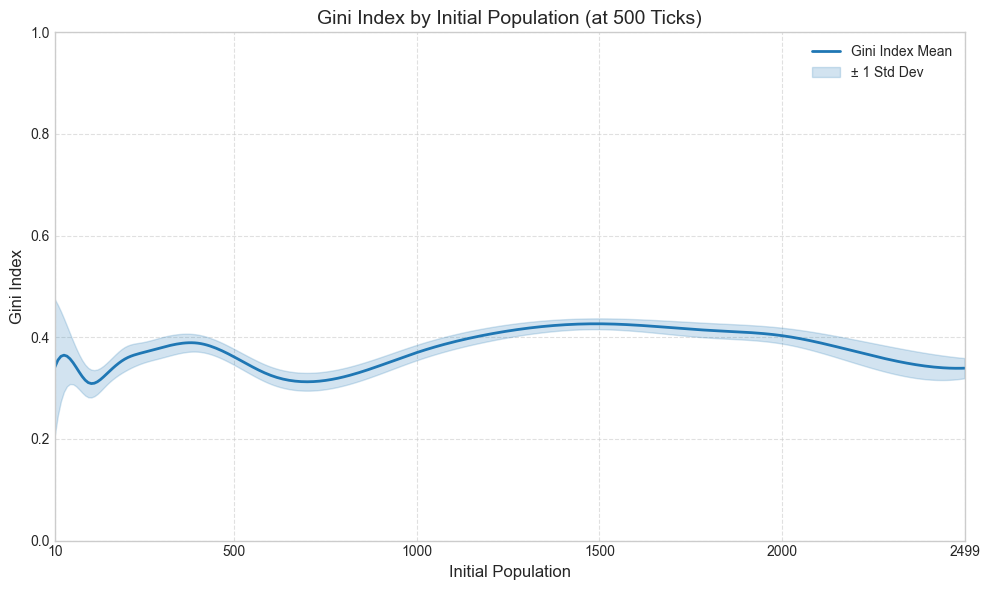

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_A_500Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['gini-index_mean'].values
y_std = df_sorted['gini-index_std'].values

# Create 300 points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (no markers)
plt.plot(x_smooth, y_mean_smooth, 
         label='Gini Index Mean', color='#1f77b4', linewidth=2)

# 4. Plot the smoothed shaded area (Mean ± Std)
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color='#1f77b4', alpha=0.2, label='± 1 Std Dev')

# 5. Chart formatting
plt.title('Gini Index by Initial Population (at 500 Ticks)', fontsize=14)
plt.xlabel('Initial Population', fontsize=12)
plt.ylabel('Gini Index', fontsize=12)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# --- KEY MODIFICATIONS START ---

# Set the limits of the X-axis (start and end only)
plt.xlim(10, 2500)

# Manually define the exact ticks you want to see
custom_ticks_x = [10, 500, 1000, 1500, 2000, 2499]
plt.xticks(custom_ticks_x)

custom_ticks_y = [0.0, 0.2, 0.4, 0.6, 0.8, 1]
plt.yticks(custom_ticks_y)


# --- KEY MODIFICATIONS END ---

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend()

# 6. Display the plot
plt.tight_layout()
plt.show()

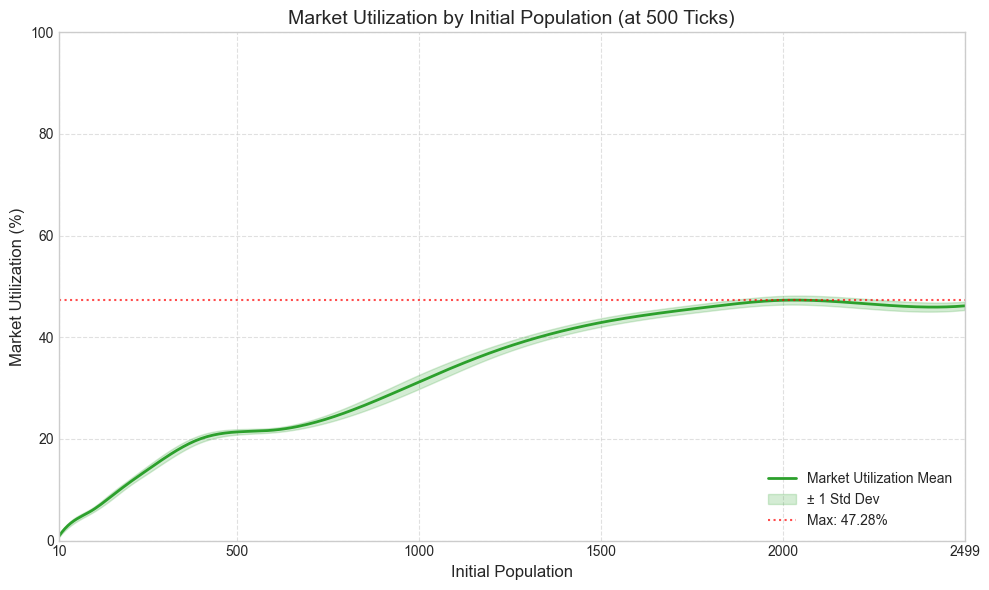

In [6]:
# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_A_500Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['get-market-utilization_mean'].values
y_std = df_sorted['get-market-utilization_std'].values

# Find the maximum point for the auxiliary lines
max_idx = np.argmax(y_mean)
x_max = x[max_idx]
y_max = y_mean[max_idx]

# Create points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (Changed to Green)
main_color = '#2ca02c' 
plt.plot(x_smooth, y_mean_smooth, 
         label='Market Utilization Mean', color=main_color, linewidth=2)

# 4. Plot the smoothed shaded area
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color=main_color, alpha=0.2, label='± 1 Std Dev')

# --- AUXILIARY LINES FOR MAX POINT ---
# Horizontal line at max Y
plt.axhline(y=y_max, color='red', linestyle=':', alpha=0.7, label=f'Max: {y_max:.2f}%')
# Vertical line at corresponding X
#plt.axvline(x=x_max, color='gray', linestyle='--', alpha=0.5)

# 5. Chart formatting
plt.title('Market Utilization by Initial Population (at 500 Ticks)', fontsize=14)
plt.xlabel('Initial Population', fontsize=12)
plt.ylabel('Market Utilization (%)', fontsize=12)

# Coordinate settings
plt.ylim(0, 100)
plt.yticks([0, 20, 40, 60, 80, 100])
plt.xlim(10, 2500)
plt.xticks([10, 500, 1000, 1500, 2000, 2499])

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend(loc='lower right')

# 6. Display the plot
plt.tight_layout()
plt.show()

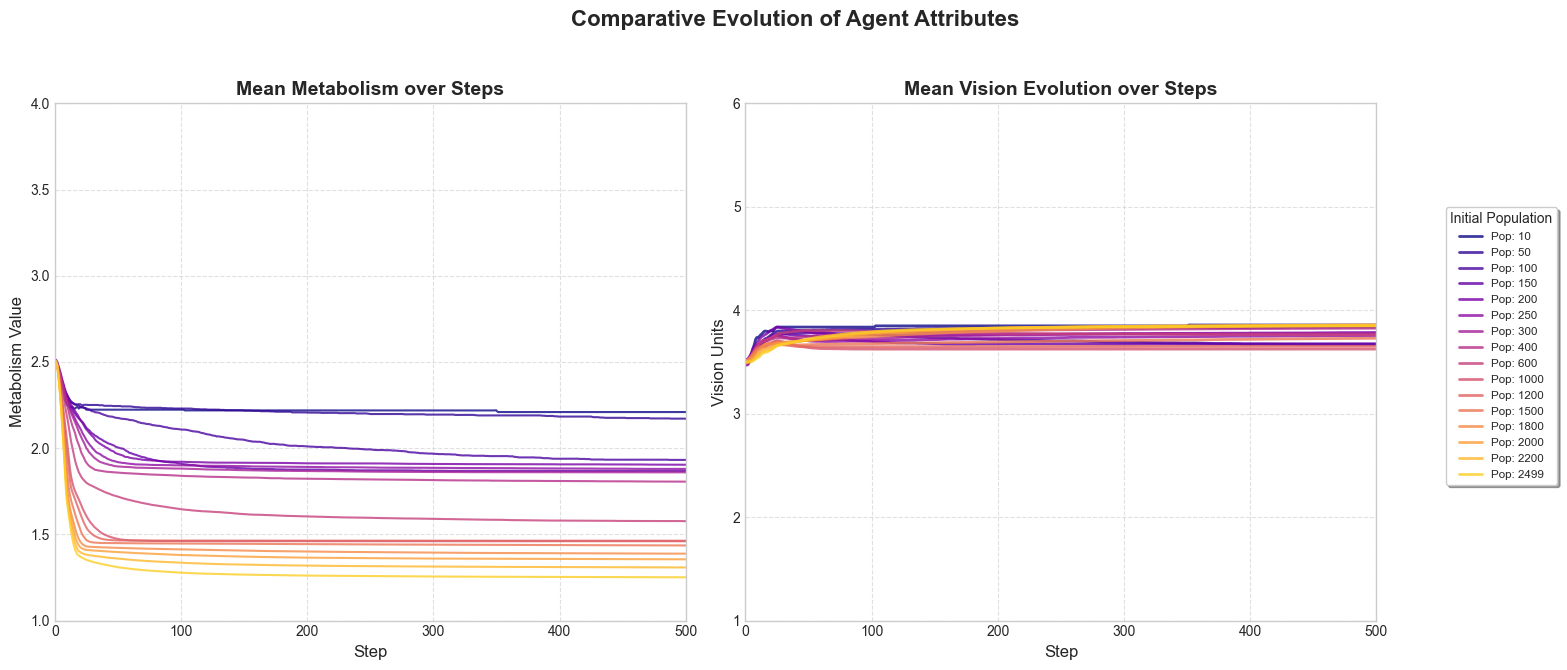

In [7]:
# 1. Setup the figure with two subplots side-by-side
# Using sharex=True as both use 'Step' as the horizontal axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Identify unique initial populations
# Standardizing column names to English 'initial-population'
unique_pops = sorted(experiment_A_summary['initial-population'].unique())

# 3. Define color maps for differentiation

colors = plt.cm.plasma(np.linspace(0, 0.9, len(unique_pops)))

# 4. Loop through each population group
for i, pop_size in enumerate(unique_pops):
    # Filtering data for the current population group
    subset = experiment_A_summary[experiment_A_summary['initial-population'] == pop_size].sort_values('step')
    
    if subset.empty:
        continue

    x = subset['step'].values
    y_meta = subset['mean-metabolism_mean'].values
    y_vision = subset['mean-vision_mean'].values
    
    # Generate smooth curves if enough points exist (cubic spline needs > 3 points)
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        
        # Smooth Metabolism data
        spl_meta = make_interp_spline(x, y_meta, k=3)
        y_meta_smooth = spl_meta(x_smooth)
        
        # Smooth Vision data
        spl_vision = make_interp_spline(x, y_vision, k=3)
        y_vision_smooth = spl_vision(x_smooth)
        
        # Plot Metabolism (Left Subplot)
        ax1.plot(x_smooth, y_meta_smooth, color=colors[i], linewidth=1.5, alpha=0.8)
        
        # Plot Vision (Right Subplot)
        # Label is added here to be captured for the shared legend
        ax2.plot(x_smooth, y_vision_smooth, label=f'Pop: {pop_size}', color=colors[i], linewidth=2, alpha=0.8)
    else:
        # Fallback for sparse data points
        ax1.plot(x, y_meta, color=colors_metabolism[i], linewidth=1.5)
        ax2.plot(x, y_vision, label=f'Pop: {pop_size}', color=colors[i], linewidth=2)

# 5. Formatting Metabolism Subplot (Left)
ax1.set_title('Mean Metabolism over Steps', fontsize=14, fontweight='bold')
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Metabolism Value', fontsize=12)
ax1.set_ylim(1, 4)
ax1.grid(True, linestyle='--', alpha=0.6)

# 6. Formatting Vision Subplot (Right)
ax2.set_title('Mean Vision Evolution over Steps', fontsize=14, fontweight='bold')
ax2.set_xlabel('Step', fontsize=12)
ax2.set_ylabel('Vision Units', fontsize=12)
ax2.set_ylim(1, 6)
ax2.set_xlim(0, 500)
ax2.grid(True, linestyle='--', alpha=0.6)

# 7. Create a single shared legend for the entire figure
# Extracting handles and labels from ax2
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title="Initial Population", loc='center right', 
           bbox_to_anchor=(0.98, 0.5), fontsize='small', frameon=True, shadow=True)

# 8. Final Layout Refinement
# title_y adjusts the main title height to avoid overlapping subplots
fig.suptitle('Comparative Evolution of Agent Attributes', fontsize=16, fontweight='bold', y=0.98)

# Adjusting layout to fit the plots and the legend nicely
plt.tight_layout(rect=[0, 0.03, 0.88, 0.95]) 

plt.show()

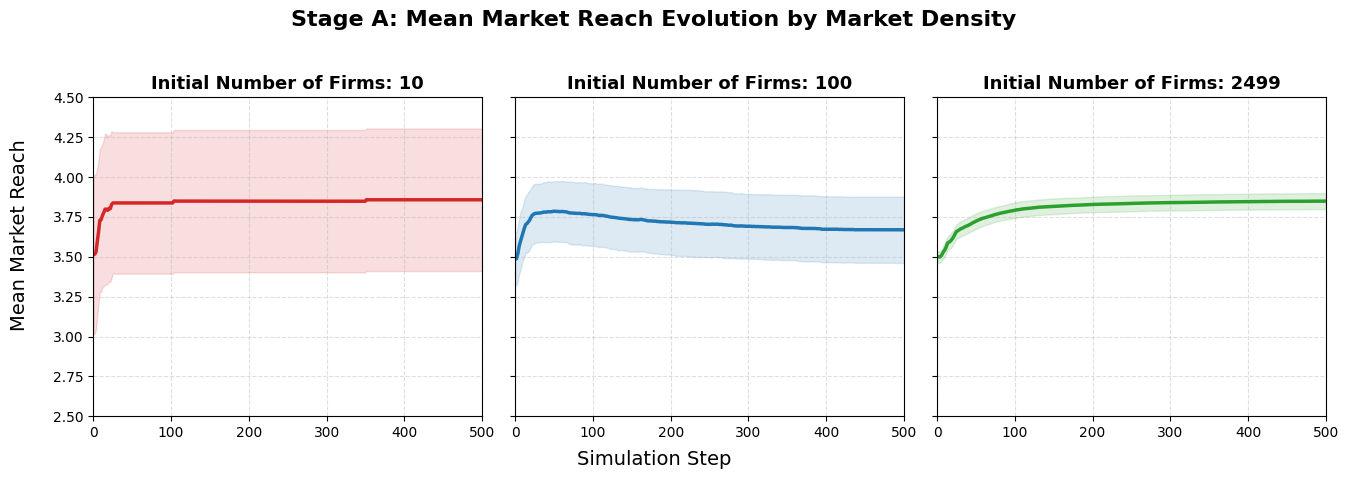

In [38]:
# 1. Setup figure with shared Y-axis enabled
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
axes = axes.flatten()

target_pops = [10, 100, 2499] 
line_colors = ['#d62728', '#1f77b4', '#2ca02c']

# 2. Loop through populations
for i, pop_size in enumerate(target_pops):
    subset = experiment_A_summary[experiment_A_summary['initial-population'] == pop_size].sort_values('step')
    
    if subset.empty: 
        continue
        
    x = subset['step'].values
    y_mean = subset['mean-vision_mean'].values
    y_std = subset['mean-vision_std'].values
    
    # Apply B-Spline smoothing
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl_mean = make_interp_spline(x, y_mean, k=3)
    y_mean_smooth = spl_mean(x_smooth)
    
    spl_std = make_interp_spline(x, y_std, k=3)
    y_std_smooth = spl_std(x_smooth)

    ax = axes[i]
    
    # Plot smoothed mean line
    ax.plot(x_smooth, y_mean_smooth, color=line_colors[i], linewidth=2.5, label=f'Firms: {pop_size}')
    
    # Plot shaded variance area
    ax.fill_between(x_smooth, 
                     y_mean_smooth - y_std_smooth, 
                     y_mean_smooth + y_std_smooth, 
                     color=line_colors[i], alpha=0.15)
    
    # Individual subplot styling
    ax.set_title(f'Initial Number of Firms: {pop_size}', fontsize=13, fontweight='semibold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylim(2.5, 4.5) 
    ax.set_xlim(0, 500) 

# 3. Global formatting
fig.suptitle('Stage A: Mean Market Reach Evolution by Market Density', 
             fontsize=16, fontweight='bold', y=0.95)

# Common Axis Labels
fig.text(0.5, 0.04, 'Simulation Step', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Mean Market Reach', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.06, 0.06, 1, 0.92])
plt.show()

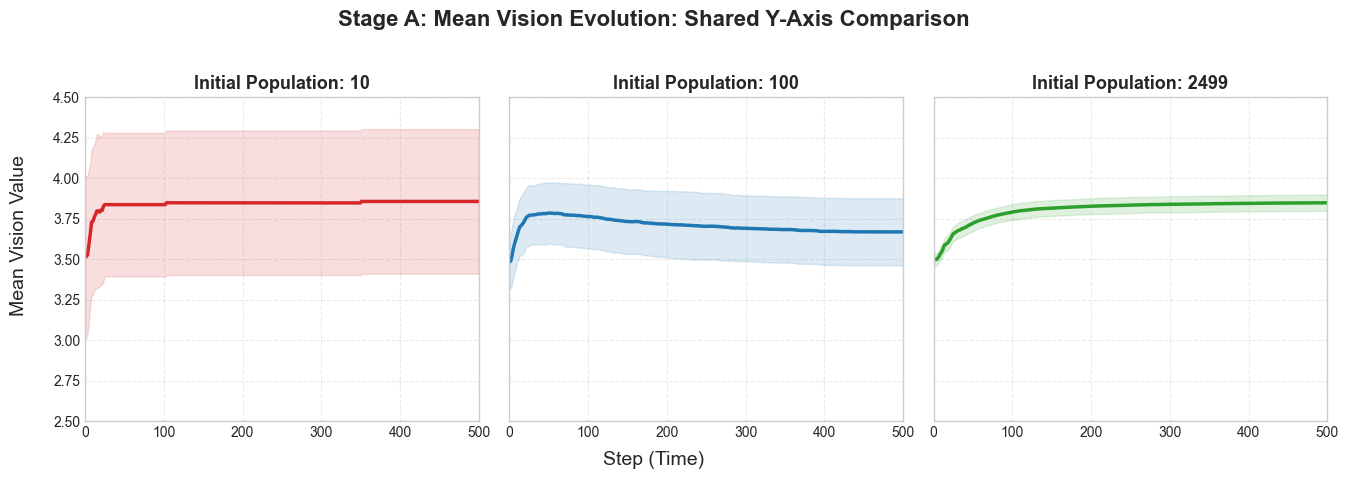

In [8]:
# 1. Setup figure with shared Y-axis enabled
# sharey=True ensures all plots use the exact same vertical scale
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
axes = axes.flatten()

# Note: Changed 600 back to 500 to match your previous target list
target_pops = [10, 100, 2499] 
line_colors = ['#d62728', '#1f77b4', '#2ca02c']

# 2. Loop through populations
for i, pop_size in enumerate(target_pops):
    subset = experiment_A_summary[experiment_A_summary['initial-population'] == pop_size].sort_values('step')
    
    if subset.empty: 
        continue
        
    x = subset['step'].values
    y_mean = subset['mean-vision_mean'].values
    y_std = subset['mean-vision_std'].values
    
    # Apply B-Spline smoothing
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl_mean = make_interp_spline(x, y_mean, k=3)
    y_mean_smooth = spl_mean(x_smooth)
    
    spl_std = make_interp_spline(x, y_std, k=3)
    y_std_smooth = spl_std(x_smooth)

    # Plotting on the specific subplot
    ax = axes[i]
    
    # Plot smoothed mean line
    ax.plot(x_smooth, y_mean_smooth, color=line_colors[i], linewidth=2.5, label=f'Pop: {pop_size}')
    
    # Plot shaded variance area
    ax.fill_between(x_smooth, 
                     y_mean_smooth - y_std_smooth, 
                     y_mean_smooth + y_std_smooth, 
                     color=line_colors[i], alpha=0.15)
    
    # Individual subplot styling
    ax.set_title(f'Initial Population: {pop_size}', fontsize=13, fontweight='semibold')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Set a consistent Y-limit for the shared axis
    ax.set_ylim(2.5, 4.5) 
    ax.set_xlim(0, 500) 

# 3. Global formatting for the shared layout
fig.suptitle('Stage A: Mean Vision Evolution: Shared Y-Axis Comparison', fontsize=16, fontweight='bold', y=0.95)

# Common Axis Labels
fig.text(0.5, 0.04, 'Step (Time)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Mean Vision Value', va='center', rotation='vertical', fontsize=14)

# Adjust layout to prevent label overlap while keeping subplots close
plt.tight_layout(rect=[0.06, 0.06, 1, 0.92])
plt.show()

In [9]:
experiment_B_1 = pd.read_csv("./experiment-B-3-1.csv")
cols_B_1 = ["maximum-sugar-endowment", "minimum-sugar-endowment", "step", "gini-index", "brand-gini-index", "market-utilization", "mean-vision", "mean-metabolism"]
experiment_B_1 = experiment_B_1[cols_B_1]

In [10]:
experiment_B_summary = experiment_B_1.groupby(['maximum-sugar-endowment', "minimum-sugar-endowment", 'step']).agg(['mean', 'std'])
experiment_B_summary.columns = [f"{col[0]}_{col[1]}" for col in experiment_B_summary.columns.values]


experiment_B_summary = experiment_B_summary.reset_index()


experiment_B_summary

,maximum-sugar-endowment,minimum-sugar-endowment,step,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
0,1,0,0,0.510333,0.032553,0.510333,0.032553,48.516191,0.984134,3.499833,0.071467,2.509500,0.050904
1,1,0,1,0.317898,0.012011,0.257014,0.005020,19.655228,0.997851,3.625510,0.083811,1.942601,0.057989
2,1,0,2,0.406218,0.011818,0.344033,0.009343,24.185597,0.997873,3.625421,0.079418,1.984823,0.063143
3,1,0,3,0.454539,0.014413,0.384672,0.009004,28.461415,1.491485,3.600584,0.091564,1.968732,0.055237
4,1,0,4,0.477537,0.011079,0.403778,0.011747,32.585790,1.490515,3.603080,0.088938,1.934160,0.070110
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36031,50,49,996,0.330810,0.007556,0.529722,0.023073,75.488964,1.024452,3.517255,0.043592,1.042810,0.008355
36032,50,49,997,0.331169,0.007573,0.529725,0.023097,75.601740,0.959756,3.516352,0.044045,1.043536,0.008021
36033,50,49,998,0.331154,0.007251,0.529710,0.023084,75.601740,0.887305,3.516863,0.043974,1.043499,0.008174
36034,50,49,999,0.331518,0.007139,0.529711,0.023099,75.746738,0.747247,3.517444,0.043870,1.044581,0.007618


In [11]:
experiment_B_1_1000Tick = experiment_B_summary[experiment_B_summary["step"] == 1000]
experiment_B_1_1000Tick

,maximum-sugar-endowment,minimum-sugar-endowment,step,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
1000,1,0,1000,0.409390,0.008798,0.406746,0.027443,79.374899,0.446527,3.508598,0.036683,1.013954,0.004271
2001,1,9,1000,0.403619,0.008993,0.406746,0.027443,77.525375,0.317989,3.509266,0.035554,1.000000,0.000000
3002,1,19,1000,0.403619,0.008993,0.406746,0.027443,77.525375,0.317989,3.509266,0.035554,1.000000,0.000000
4003,1,29,1000,0.403619,0.008993,0.406746,0.027443,77.525375,0.317989,3.509266,0.035554,1.000000,0.000000
5004,1,39,1000,0.403619,0.008993,0.406746,0.027443,77.525375,0.317989,3.509266,0.035554,1.000000,0.000000
6005,1,49,1000,0.403695,0.008972,0.408874,0.026890,77.544708,0.326685,3.511877,0.035576,1.000000,0.000000
7006,10,0,1000,0.190998,0.004258,0.493598,0.034840,75.975512,0.175664,3.501305,0.041665,1.000000,0.000000
8007,10,9,1000,0.258106,0.003360,0.508098,0.027163,75.885291,0.253436,3.503756,0.050440,1.000000,0.000000
9008,10,19,1000,0.248859,0.023941,0.510754,0.029922,75.907846,0.196639,3.515551,0.040561,1.000000,0.000000
10009,10,29,1000,0.253439,0.017736,0.510366,0.029382,75.927179,0.226307,3.511410,0.042931,1.000000,0.000000


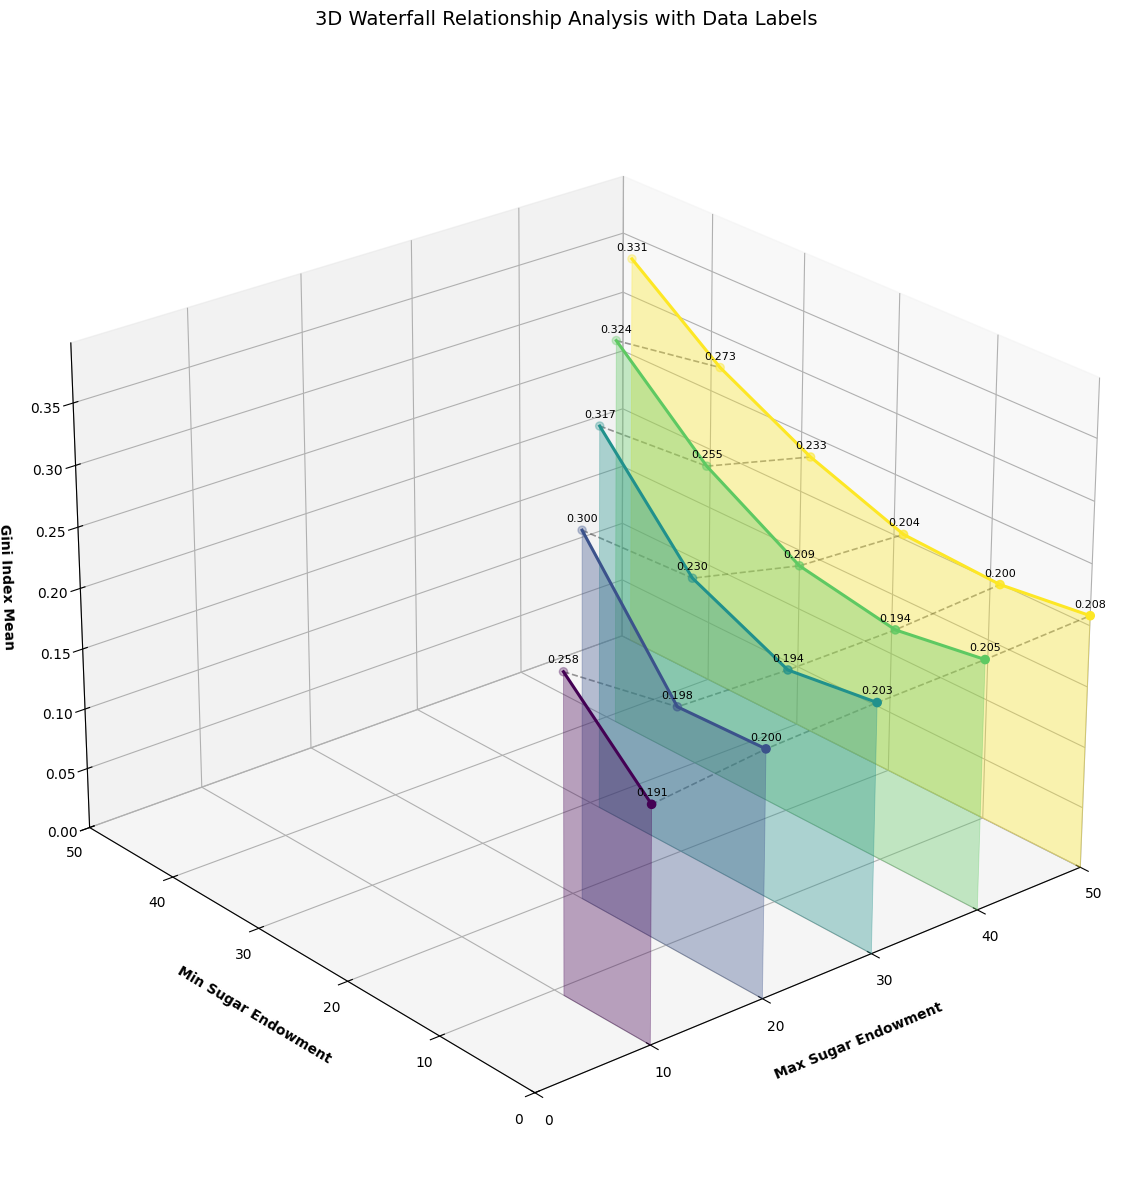

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()

    # Remove specific outlier/edge case: (max=1, min=0)
    df_plot = df_plot[~(
        (df_plot["maximum-sugar-endowment"] == 1) &
        (df_plot["minimum-sugar-endowment"] == 0)
    )]

    # Apply logical constraint: Max must be greater than Min
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]

    # Ensure data is sorted for consistent line drawing
    df_plot = df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])
    
    return df_plot

# Assuming experiment_B_1_1000Tick is already defined in your environment
df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(16, 12)) # Slightly larger to accommodate labels
ax = fig.add_subplot(111, projection='3d')

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOGIC
# ==========================================

# --- A. Waterfall Lines, Shading & Data Labels (Grouped by Max) ---
verts = []
for i, max_val in enumerate(max_values):
    group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")

    y_coords = group["minimum-sugar-endowment"].values
    z_coords = group["gini-index_mean"].values
    x_coords = np.full(len(y_coords), max_val)

    # Main plot line
    ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=2.2, zorder=10)

    # Scatter points for markers
    ax.scatter(x_coords, y_coords, z_coords, color=colors[i], s=35, depthshade=True)

    # Add text labels for each point
    for x, y, z in zip(x_coords, y_coords, z_coords):
        # Format label to 3 decimal places
        label = f'{z:.3f}'
        # Add a small offset in Z direction to lift the text above the point
        ax.text(x, y, z + 0.005, label, 
                size=8, 
                zorder=20, 
                color='black', 
                ha='center', 
                va='bottom')

    # Prepare vertices for PolyCollection (Shading under the curves)
    path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
    path_z = np.concatenate([[0], z_coords, [0]])
    verts.append(list(zip(path_y, path_z)))

# Add shading areas
poly = PolyCollection(verts, facecolors=colors, alpha=0.35, edgecolors=colors, linewidths=0.6)
ax.add_collection3d(poly, zs=max_values, zdir='x')

# --- B. Transverse Connection Lines (Grouped by Min) ---
for min_val in min_values:
    group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")

    x_coords = group["maximum-sugar-endowment"].values
    y_coords = np.full(len(x_coords), min_val)
    z_coords = group["gini-index_mean"].values

    # Dashed lines connecting the waterfalls
    ax.plot(x_coords, y_coords, z_coords, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

# ==========================================
# 4. AXIS & VIEW STYLING
# ==========================================
ax.set_xlabel('Max Sugar Endowment', labelpad=15, fontweight='bold')
ax.set_ylabel('Min Sugar Endowment', labelpad=15, fontweight='bold')
ax.set_zlabel('Gini Index Mean', labelpad=10, fontweight='bold')
ax.set_title('3D Waterfall Relationship Analysis with Data Labels', pad=30, fontsize=14)

# Dynamic axis limits
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
# Extend Z-limit slightly more to ensure top labels aren't cut off
ax.set_zlim(0, df_plot["gini-index_mean"].max() * 1.2)

# Set perspective
ax.view_init(elev=25, azim=-130)

plt.tight_layout()
plt.show()

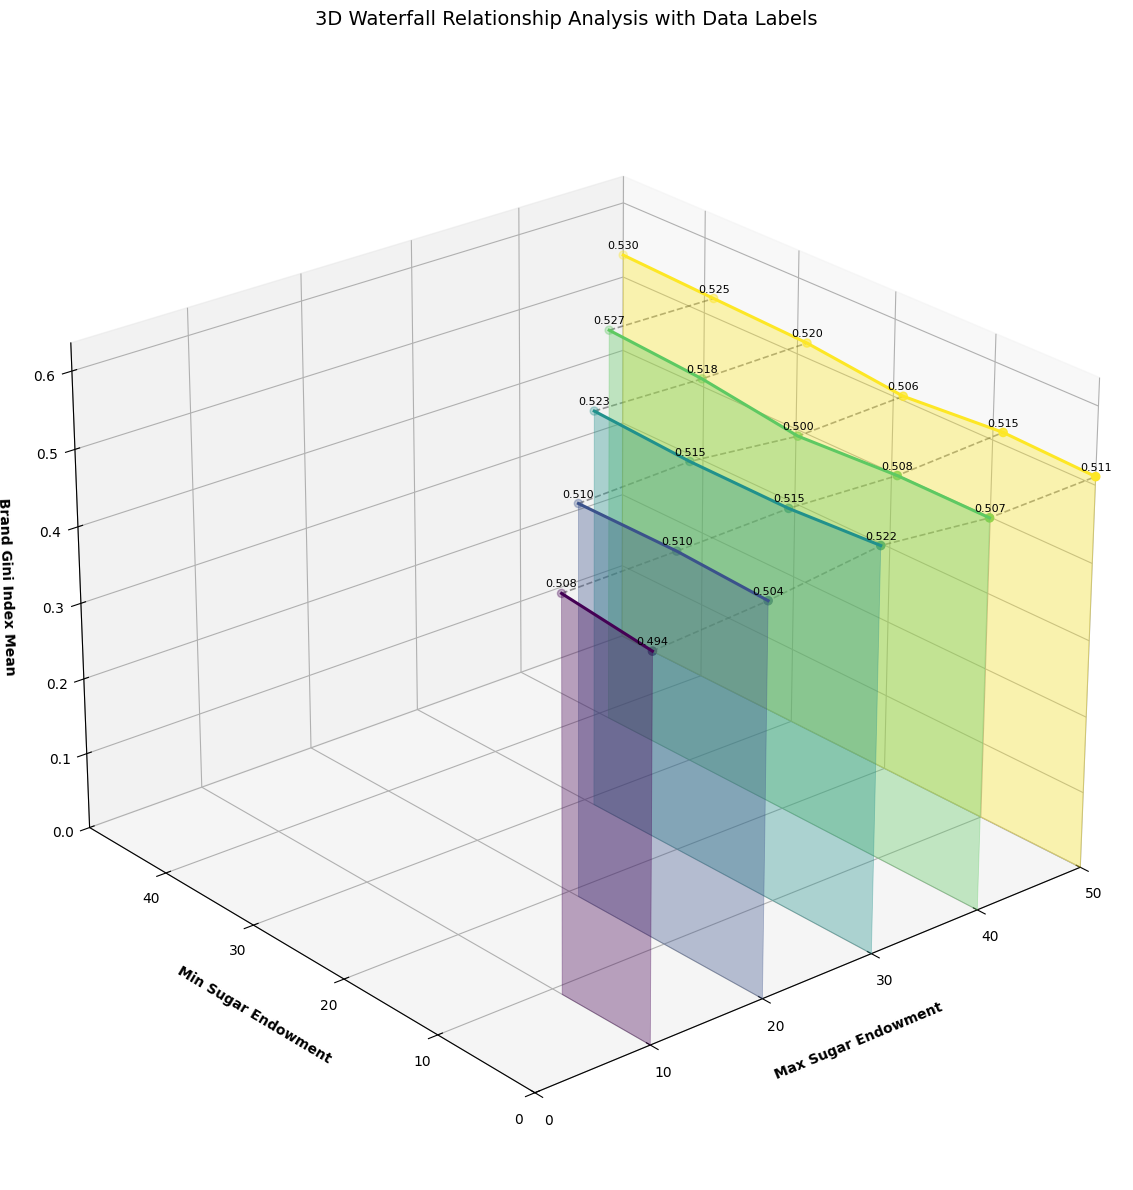

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()

    # Remove specific outlier/edge case: (max=1, min=0)
    df_plot = df_plot[~(
        (df_plot["maximum-sugar-endowment"] == 1) &
        (df_plot["minimum-sugar-endowment"] == 0)
    )]

    # Apply logical constraint: Max must be greater than Min
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]

    # Ensure data is sorted for consistent line drawing
    df_plot = df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])
    
    return df_plot

# Assuming experiment_B_1_1000Tick is already defined in your environment
df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(16, 12)) # Slightly larger to accommodate labels
ax = fig.add_subplot(111, projection='3d')

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOGIC
# ==========================================

# --- A. Waterfall Lines, Shading & Data Labels (Grouped by Max) ---
verts = []
for i, max_val in enumerate(max_values):
    group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")

    y_coords = group["minimum-sugar-endowment"].values
    z_coords = group["brand-gini-index_mean"].values
    x_coords = np.full(len(y_coords), max_val)

    # Main plot line
    ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=2.2, zorder=10)

    # Scatter points for markers
    ax.scatter(x_coords, y_coords, z_coords, color=colors[i], s=35, depthshade=True)

    # Add text labels for each point
    for x, y, z in zip(x_coords, y_coords, z_coords):
        # Format label to 3 decimal places
        label = f'{z:.3f}'
        # Add a small offset in Z direction to lift the text above the point
        ax.text(x, y, z + 0.005, label, 
                size=8, 
                zorder=20, 
                color='black', 
                ha='center', 
                va='bottom')

    # Prepare vertices for PolyCollection (Shading under the curves)
    path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
    path_z = np.concatenate([[0], z_coords, [0]])
    verts.append(list(zip(path_y, path_z)))

# Add shading areas
poly = PolyCollection(verts, facecolors=colors, alpha=0.35, edgecolors=colors, linewidths=0.6)
ax.add_collection3d(poly, zs=max_values, zdir='x')

# --- B. Transverse Connection Lines (Grouped by Min) ---
for min_val in min_values:
    group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")

    x_coords = group["maximum-sugar-endowment"].values
    y_coords = np.full(len(x_coords), min_val)
    z_coords = group["brand-gini-index_mean"].values

    # Dashed lines connecting the waterfalls
    ax.plot(x_coords, y_coords, z_coords, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

# ==========================================
# 4. AXIS & VIEW STYLING
# ==========================================
ax.set_xlabel('Max Sugar Endowment', labelpad=15, fontweight='bold')
ax.set_ylabel('Min Sugar Endowment', labelpad=15, fontweight='bold')
ax.set_zlabel('Brand Gini Index Mean', labelpad=10, fontweight='bold')
ax.set_title('3D Waterfall Relationship Analysis with Data Labels', pad=30, fontsize=14)

# Dynamic axis limits
ax.set_xlim(0, 50)
ax.set_ylim(min_values.min(), min_values.max())
# Extend Z-limit slightly more to ensure top labels aren't cut off
ax.set_zlim(0, df_plot["brand-gini-index_mean"].max() * 1.2)

# Set perspective
ax.view_init(elev=25, azim=-130)

plt.tight_layout()
plt.show()

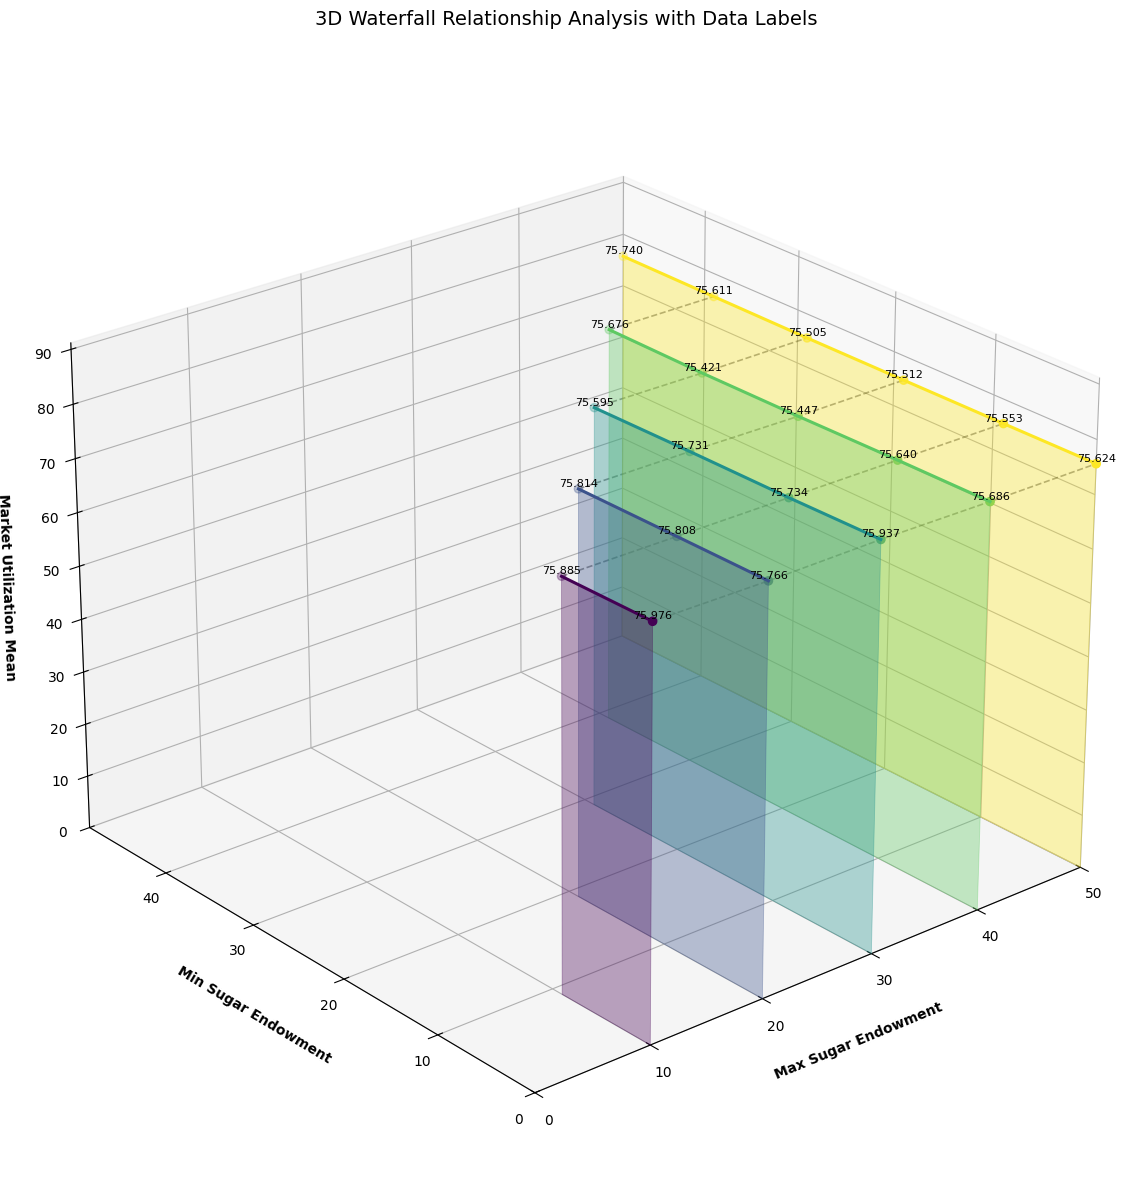

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()

    # Remove specific outlier/edge case: (max=1, min=0)
    df_plot = df_plot[~(
        (df_plot["maximum-sugar-endowment"] == 1) &
        (df_plot["minimum-sugar-endowment"] == 0)
    )]

    # Apply logical constraint: Max must be greater than Min
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]

    # Ensure data is sorted for consistent line drawing
    df_plot = df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])
    
    return df_plot

# Assuming experiment_B_1_1000Tick is already defined in your environment
df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(16, 12)) # Slightly larger to accommodate labels
ax = fig.add_subplot(111, projection='3d')

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOGIC
# ==========================================

# --- A. Waterfall Lines, Shading & Data Labels (Grouped by Max) ---
verts = []
for i, max_val in enumerate(max_values):
    group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")

    y_coords = group["minimum-sugar-endowment"].values
    z_coords = group["market-utilization_mean"].values
    x_coords = np.full(len(y_coords), max_val)

    # Main plot line
    ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=2.2, zorder=10)

    # Scatter points for markers
    ax.scatter(x_coords, y_coords, z_coords, color=colors[i], s=35, depthshade=True)

    # Add text labels for each point
    for x, y, z in zip(x_coords, y_coords, z_coords):
        # Format label to 3 decimal places
        label = f'{z:.3f}'
        # Add a small offset in Z direction to lift the text above the point
        ax.text(x, y, z + 0.005, label, 
                size=8, 
                zorder=20, 
                color='black', 
                ha='center', 
                va='bottom')

    # Prepare vertices for PolyCollection (Shading under the curves)
    path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
    path_z = np.concatenate([[0], z_coords, [0]])
    verts.append(list(zip(path_y, path_z)))

# Add shading areas
poly = PolyCollection(verts, facecolors=colors, alpha=0.35, edgecolors=colors, linewidths=0.6)
ax.add_collection3d(poly, zs=max_values, zdir='x')

# --- B. Transverse Connection Lines (Grouped by Min) ---
for min_val in min_values:
    group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")

    x_coords = group["maximum-sugar-endowment"].values
    y_coords = np.full(len(x_coords), min_val)
    z_coords = group["market-utilization_mean"].values

    # Dashed lines connecting the waterfalls
    ax.plot(x_coords, y_coords, z_coords, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

# ==========================================
# 4. AXIS & VIEW STYLING
# ==========================================
ax.set_xlabel('Expansion Threshold (ET)', labelpad=15, fontweight='bold')
ax.set_ylabel('Minimum Entry Wealth (MW)', labelpad=15, fontweight='bold')
ax.set_zlabel('Market Utilization (%)', labelpad=10, fontweight='bold')
ax.set_title('Market Utilization by Entry Conditions (ET × MW)', pad=30, fontsize=14)

# Dynamic axis limits
ax.set_xlim(0, 50)
ax.set_ylim(min_values.min(), min_values.max())
# Extend Z-limit slightly more to ensure top labels aren't cut off
ax.set_zlim(0, df_plot["market-utilization_mean"].max() * 1.2)

# Set perspective
ax.view_init(elev=25, azim=-130)

plt.tight_layout()
plt.show()

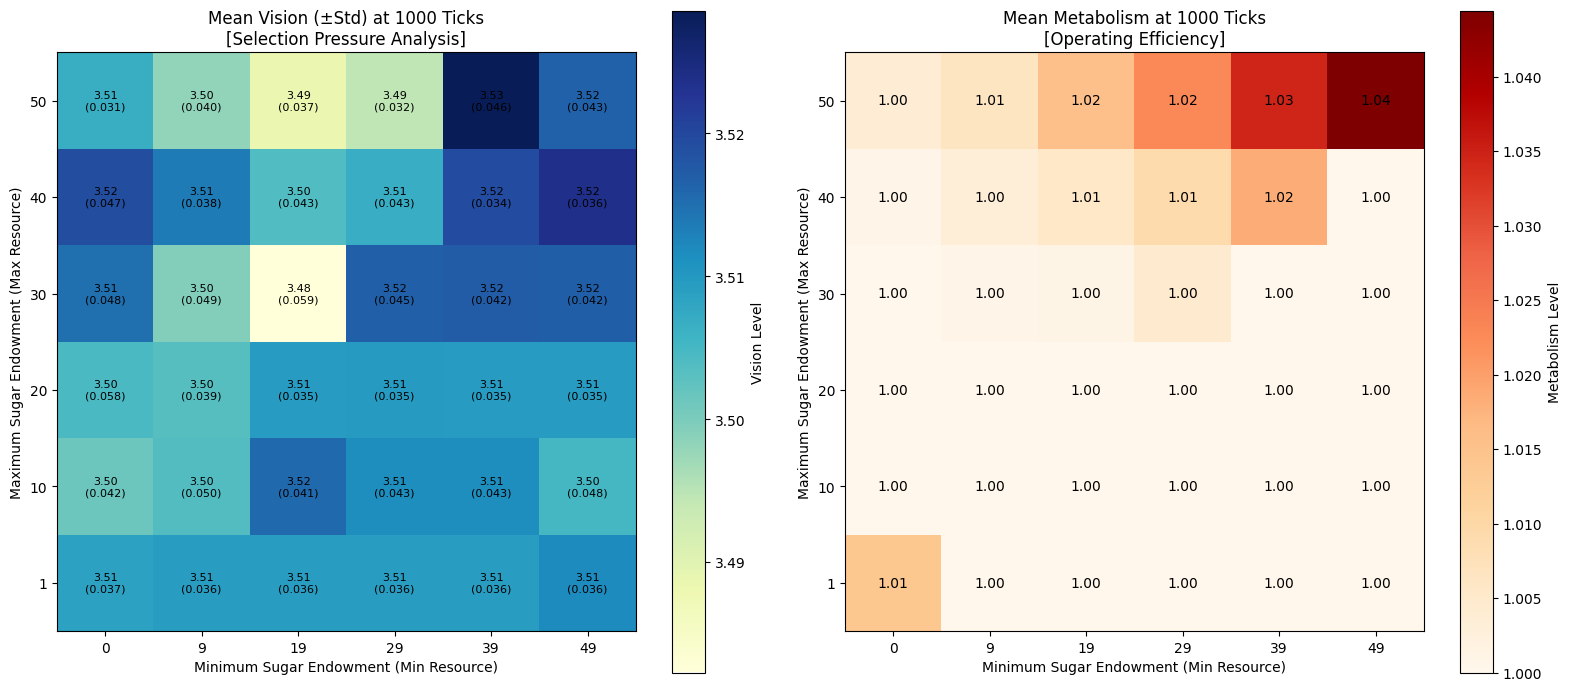

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 提取唯一坐标轴标签并排序
# 确保坐标轴能够覆盖数据中的所有参数梯度
max_vals = sorted(experiment_B_1_1000Tick['maximum-sugar-endowment'].unique())
min_vals = sorted(experiment_B_1_1000Tick['minimum-sugar-endowment'].unique())

# 2. 初始化数据矩阵 (NaN 填充)
vision_mat = np.full((len(max_vals), len(min_vals)), np.nan)
meta_mat = np.full((len(max_vals), len(min_vals)), np.nan)
annot_v = [] 

# 3. 填充数据
for i, row_val in enumerate(max_vals):
    row_annot = []
    for j, col_val in enumerate(min_vals):
        # 匹配对应参数的数据行
        subset = experiment_B_1_1000Tick[
            (experiment_B_1_1000Tick['maximum-sugar-endowment'] == row_val) & 
            (experiment_B_1_1000Tick['minimum-sugar-endowment'] == col_val)
        ]
        
        if not subset.empty:
            v_mean_val = subset['mean-vision_mean'].values[0]
            v_std_val = subset['mean-vision_std'].values[0]
            m_mean_val = subset['mean-metabolism_mean'].values[0]
            
            vision_mat[i, j] = v_mean_val
            meta_mat[i, j] = m_mean_val
            # 准备标注文本: 均值 (标准差)
            row_annot.append(f"{v_mean_val:.2f}\n({v_std_val:.3f})")
        else:
            row_annot.append("")
    annot_v.append(row_annot)

# 4. 绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Vision 热力图 (洞察力演化) ---
# 使用 origin='lower' 确保 Max 值从小到大向上排列
im1 = ax1.imshow(vision_mat, cmap='YlGnBu', origin='lower')
ax1.set_title("Mean Vision (±Std) at 1000 Ticks\n[Selection Pressure Analysis]")
plt.colorbar(im1, ax=ax1, label='Vision Level')

# --- Metabolism 热力图 (运营成本演化) ---
im2 = ax2.imshow(meta_mat, cmap='OrRd', origin='lower')
ax2.set_title("Mean Metabolism at 1000 Ticks\n[Operating Efficiency]")
plt.colorbar(im2, ax=ax2, label='Metabolism Level')

# 5. 设置坐标轴
for ax in [ax1, ax2]:
    ax.set_xticks(range(len(min_vals)))
    ax.set_xticklabels(min_vals)
    ax.set_yticks(range(len(max_vals)))
    ax.set_yticklabels(max_vals)
    ax.set_xlabel("Minimum Sugar Endowment (Min Resource)")
    ax.set_ylabel("Maximum Sugar Endowment (Max Resource)")

# 6. 在格子里添加文字标注
for i in range(len(max_vals)):
    for j in range(len(min_vals)):
        if not np.isnan(vision_mat[i, j]):
            # 标注 Vision 的均值和标准差
            ax1.text(j, i, annot_v[i][j], ha="center", va="center", fontsize=8)
            # 标注 Metabolism 的均值
            ax2.text(j, i, f"{meta_mat[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [149]:
experiment_B_2 = pd.read_csv("./experiment-B-2.csv")
#vals_A = ["initial-population","step","population","get-market-utilization","gini-index","mean-vision","mean-metabolism"]
#experiment_A = experiment_A[vals_A]
experiment_B_2

,maximum-sugar-endowment,visualization,minimum-sugar-endowment,initial-population,step,count-turtles,gini-index,brand-gini-index,market-utilization,mean-vision,mean-metabolism
0,20,color-agents-by-brand,10,10,0,10,0.126277,0.126277,0.966651,4.600000,2.0
1,20,color-agents-by-brand,10,10,0,10,0.127338,0.127338,1.401643,2.600000,2.9
2,20,color-agents-by-brand,10,10,0,10,0.126389,0.126389,1.353311,3.800000,2.8
3,20,color-agents-by-brand,10,10,0,10,0.109589,0.109589,1.546641,2.600000,3.2
4,20,color-agents-by-brand,10,10,0,10,0.085333,0.085333,1.353311,3.300000,2.8
...,...,...,...,...,...,...,...,...,...,...,...
300295,20,color-agents-by-brand,10,1000,996,1591,0.199843,0.527598,76.897052,3.471402,1.0
300296,20,color-agents-by-brand,10,1000,997,1591,0.199843,0.527598,76.897052,3.471402,1.0
300297,20,color-agents-by-brand,10,1000,998,1591,0.199843,0.527598,76.897052,3.471402,1.0
300298,20,color-agents-by-brand,10,1000,999,1591,0.199843,0.527598,76.897052,3.471402,1.0


In [160]:
import pandas as pd
import numpy as np

# 1. 读取并筛选
experiment_B_2 = pd.read_csv("./Stage-B-2")
B_2_col = [
    "maximum-sugar-endowment", "minimum-sugar-endowment", 
    "initial-population", "step", "count-turtles", 
    "gini-index", "brand-gini-index", "market-utilization", 
    "mean-vision", "mean-metabolism"
]


experiment_B_2_summary = experiment_B_2[B_2_col].groupby(['initial-population', 'step']).agg(['mean', 'std'])


experiment_B_2_summary.columns = [f"{col[0]}_{col[1]}" for col in experiment_B_2_summary.columns.values]


experiment_B_2_summary = experiment_B_2_summary.reset_index()


experiment_B_2_summary

,initial-population,step,maximum-sugar-endowment_mean,maximum-sugar-endowment_std,minimum-sugar-endowment_mean,minimum-sugar-endowment_std,count-turtles_mean,count-turtles_std,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
0,10,0,20.0,0.0,10.0,0.0,10.000000,0.000000,0.109706,0.023560,0.109706,0.023560,1.255035,0.175639,3.776667,0.532193,2.596667,0.363397
1,10,1,20.0,0.0,10.0,0.0,10.233333,0.430183,0.127827,0.034442,0.124747,0.034045,1.272757,0.176485,3.763030,0.509051,2.576667,0.369735
2,10,2,20.0,0.0,10.0,0.0,10.700000,0.876907,0.162819,0.047116,0.164993,0.052806,1.324311,0.160853,3.757086,0.511325,2.576127,0.372204
3,10,3,20.0,0.0,10.0,0.0,11.233333,1.304722,0.201382,0.056403,0.210441,0.071479,1.390366,0.186408,3.778112,0.485074,2.581417,0.376374
4,10,4,20.0,0.0,10.0,0.0,11.733333,1.659525,0.219609,0.049119,0.240545,0.068302,1.437087,0.236757,3.832911,0.454970,2.553477,0.390042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10005,1000,996,20.0,0.0,10.0,0.0,1591.600000,6.201223,0.203071,0.003922,0.496205,0.016561,76.926051,0.299721,3.507222,0.047301,1.000000,0.000000
10006,1000,997,20.0,0.0,10.0,0.0,1591.600000,6.201223,0.203070,0.003922,0.496204,0.016563,76.926051,0.299721,3.507222,0.047301,1.000000,0.000000
10007,1000,998,20.0,0.0,10.0,0.0,1591.666667,6.199740,0.203071,0.003922,0.496204,0.016562,76.935718,0.301276,3.507137,0.047280,1.000084,0.000359
10008,1000,999,20.0,0.0,10.0,0.0,1591.666667,6.199740,0.203071,0.003922,0.496204,0.016563,76.935718,0.301276,3.507137,0.047280,1.000084,0.000359


In [161]:
experiment_B_2_1000Tick = experiment_B_2_summary[experiment_B_2_summary["step"] == 1000]
experiment_B_2_1000Tick.rename(name_b_2, inplace = True)
experiment_B_2_1000Tick

C:\Users\17902\AppData\Local\Temp\ipykernel_25304\1785602156.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,initial-population,step,maximum-sugar-endowment_mean,maximum-sugar-endowment_std,minimum-sugar-endowment_mean,minimum-sugar-endowment_std,count-turtles_mean,count-turtles_std,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
1000,10,1000,20.0,0.0,10.0,0.0,1552.233333,1.774986,0.203666,0.003884,0.404981,0.122204,75.029805,0.090184,3.504357,0.044710,1.000086,0.000368
2001,50,1000,20.0,0.0,10.0,0.0,1554.266667,2.572177,0.203174,0.004154,0.476817,0.068878,75.128081,0.124751,3.504151,0.035068,1.000086,0.000368
3002,100,1000,20.0,0.0,10.0,0.0,1556.400000,2.761809,0.203321,0.004127,0.506474,0.047426,75.229580,0.139476,3.497633,0.042828,1.000064,0.000258
4003,150,1000,20.0,0.0,10.0,0.0,1558.133333,3.191944,0.205106,0.003882,0.506711,0.045360,75.316578,0.140282,3.489673,0.047914,1.000107,0.000382
5004,200,1000,20.0,0.0,10.0,0.0,1560.133333,3.224190,0.203643,0.003978,0.520810,0.027094,75.405188,0.155833,3.497411,0.051295,1.000000,0.000000
6005,250,1000,20.0,0.0,10.0,0.0,1562.466667,3.501067,0.205070,0.004174,0.500207,0.032713,75.519575,0.169699,3.510042,0.039009,1.000021,0.000117
7006,300,1000,20.0,0.0,10.0,0.0,1564.433333,3.936420,0.203284,0.003322,0.504279,0.030030,75.613018,0.190257,3.501401,0.043368,1.000000,0.000000
8007,400,1000,20.0,0.0,10.0,0.0,1567.733333,3.990794,0.203890,0.003633,0.506039,0.018389,75.772515,0.192885,3.519454,0.040076,1.000000,0.000000
9008,600,1000,20.0,0.0,10.0,0.0,1575.600000,4.140631,0.203921,0.005349,0.507680,0.019287,76.154342,0.198869,3.520865,0.048998,1.000021,0.000116
10009,1000,1000,20.0,0.0,10.0,0.0,1591.666667,6.199740,0.203073,0.003923,0.496203,0.016564,76.935718,0.301276,3.507137,0.047280,1.000084,0.000359


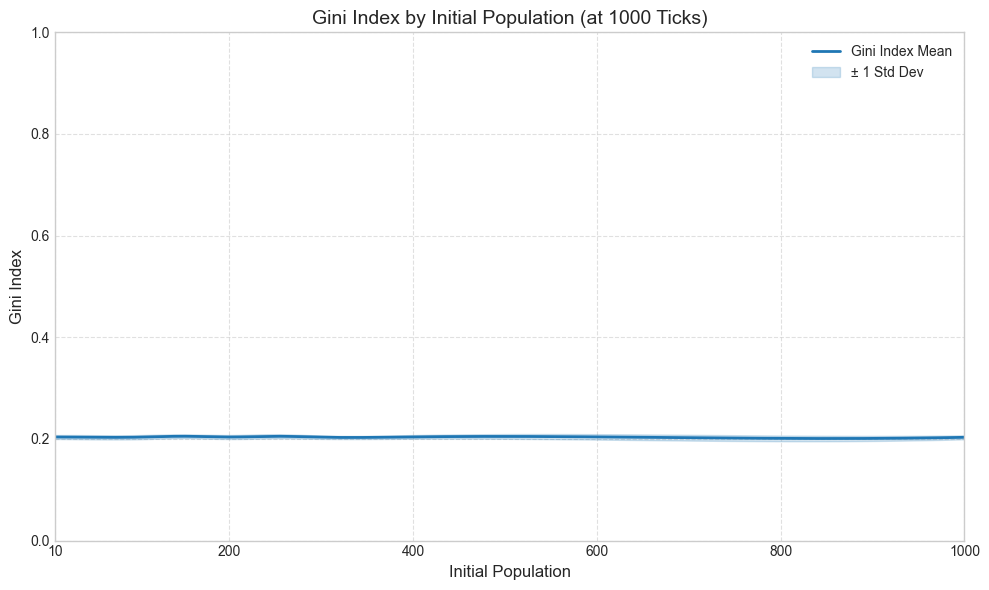

In [165]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_B_2_1000Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['gini-index_mean'].values
y_std = df_sorted['gini-index_std'].values

# Create 300 points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (no markers)
plt.plot(x_smooth, y_mean_smooth, 
         label='Gini Index Mean', color='#1f77b4', linewidth=2)

# 4. Plot the smoothed shaded area (Mean ± Std)
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color='#1f77b4', alpha=0.2, label='± 1 Std Dev')

# 5. Chart formatting
plt.title('Gini Index by Initial Population (at 1000 Ticks)', fontsize=14)
plt.xlabel('Initial Population', fontsize=12)
plt.ylabel('Gini Index', fontsize=12)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# --- KEY MODIFICATIONS START ---

# Set the limits of the X-axis (start and end only)
plt.xlim(10, 1000)

# Manually define the exact ticks you want to see
custom_ticks_x = [10, 200, 400, 600, 800, 1000]
plt.xticks(custom_ticks_x)

custom_ticks_y = [0.0, 0.2, 0.4, 0.6, 0.8, 1]
plt.yticks(custom_ticks_y)


# --- KEY MODIFICATIONS END ---

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend()

# 6. Display the plot
plt.tight_layout()
plt.show()

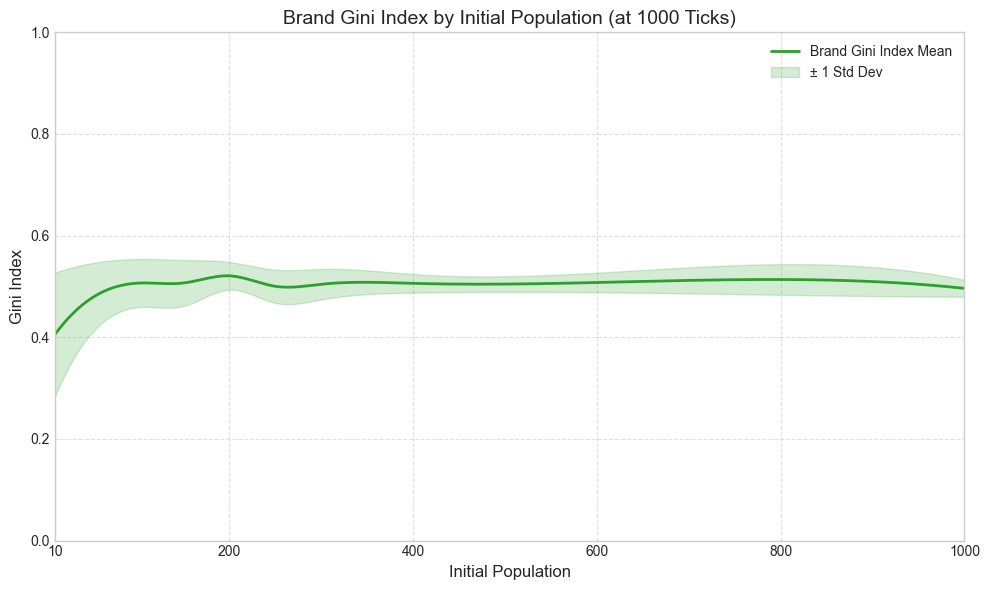

In [167]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_B_2_1000Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['brand-gini-index_mean'].values
y_std = df_sorted['brand-gini-index_std'].values

# Create 300 points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (no markers)
plt.plot(x_smooth, y_mean_smooth, 
         label='Brand Gini Index Mean', color='#2ca02c', linewidth=2)

# 4. Plot the smoothed shaded area (Mean ± Std)
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color='#2ca02c', alpha=0.2, label='± 1 Std Dev')

# 5. Chart formatting
plt.title('Brand Gini Index by Initial Population (at 1000 Ticks)', fontsize=14)
plt.xlabel('Initial Population', fontsize=12)
plt.ylabel('Gini Index', fontsize=12)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# --- KEY MODIFICATIONS START ---

# Set the limits of the X-axis (start and end only)
plt.xlim(10, 1000)

# Manually define the exact ticks you want to see
custom_ticks_x = [10, 200, 400, 600, 800, 1000]
plt.xticks(custom_ticks_x)

custom_ticks_y = [0.0, 0.2, 0.4, 0.6, 0.8, 1]
plt.yticks(custom_ticks_y)


# --- KEY MODIFICATIONS END ---

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend()

# 6. Display the plot
plt.tight_layout()
plt.show()

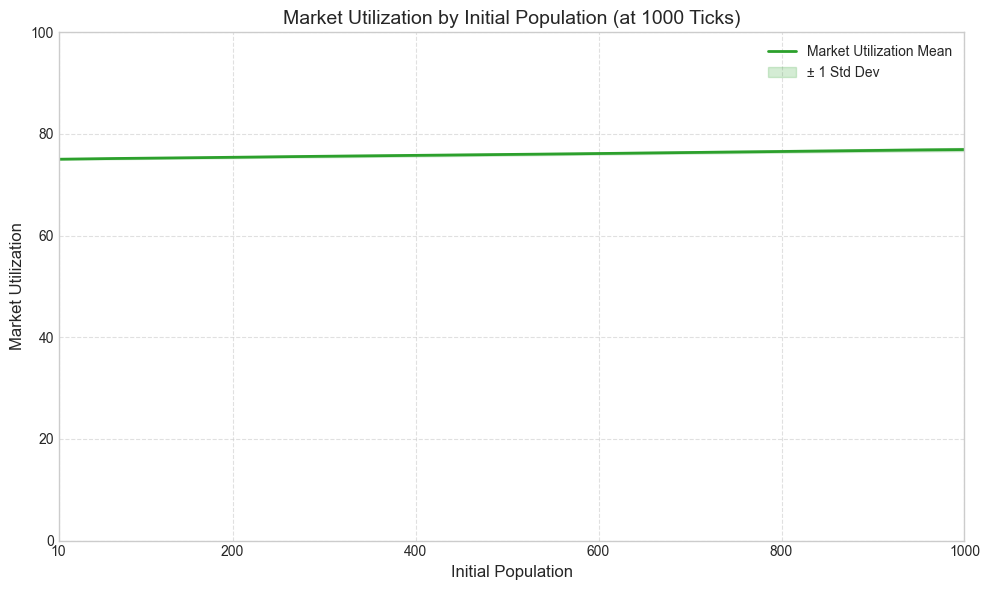

In [169]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_B_2_1000Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['market-utilization_mean'].values
y_std = df_sorted['market-utilization_std'].values

# Create 300 points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (no markers)
plt.plot(x_smooth, y_mean_smooth, 
         label='Market Utilization Mean', color='#2ca02c', linewidth=2)

# 4. Plot the smoothed shaded area (Mean ± Std)
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color='#2ca02c', alpha=0.2, label='± 1 Std Dev')

# 5. Chart formatting
plt.title('Market Utilization by Initial Population (at 1000 Ticks)', fontsize=14)
plt.xlabel('Initial Population', fontsize=12)
plt.ylabel('Market Utilization', fontsize=12)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# --- KEY MODIFICATIONS START ---

# Set the limits of the X-axis (start and end only)
plt.xlim(10, 1000)

# Manually define the exact ticks you want to see
custom_ticks_x = [10, 200, 400, 600, 800, 1000]
plt.xticks(custom_ticks_x)

custom_ticks_y = [0, 20, 40, 60, 80, 100]
plt.yticks(custom_ticks_y)


# --- KEY MODIFICATIONS END ---

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend()

# 6. Display the plot
plt.tight_layout()
plt.show()

In [23]:
experiment_B_efficiency_gain = pd.read_csv("./Stage-B-2.csv")
                                           
experiment_B_efficiency_gain

,run-number,efficiency-gain,step,count-turtles,gini-index,brand-gini-index,market-utilization,mean-vision,mean-metabolism
0,9,0.0,0,400,0.119608,0.119608,47.462542,3.382500,2.455000
1,3,0.0,0,400,0.118044,0.118044,48.235863,3.550000,2.495000
2,5,0.0,0,400,0.116507,0.116507,47.172547,3.522500,2.440000
3,4,0.0,0,400,0.116484,0.116484,48.719188,3.377500,2.520000
4,2,0.0,0,400,0.124751,0.124751,49.395843,3.490000,2.555000
...,...,...,...,...,...,...,...,...,...
330325,330,1.0,996,2059,0.533858,0.667879,141.275979,3.515784,1.419621
330326,330,1.0,997,2056,0.533184,0.667886,140.695988,3.517510,1.415856
330327,330,1.0,998,2055,0.532960,0.667894,140.599323,3.518248,1.415572
330328,330,1.0,999,2055,0.532947,0.667902,140.599323,3.518735,1.415572


In [28]:
import pandas as pd

# 1. 按照变量和步长进行分组聚合
# 注意：聚合后，'efficiency-gain' 和 'step' 变成了 MultiIndex（多重索引）
experiment_B_efficiency_gain_summary = experiment_B_efficiency_gain.groupby(['efficiency-gain', 'step']).agg(['mean', 'std'])

# 2. 扁平化列名（将多层列名如 ('vision', 'mean') 转换为 'vision_mean'）
experiment_B_efficiency_gain_summary.columns = [f"{col[0]}_{col[1]}" for col in experiment_B_efficiency_gain_summary.columns.values]

# 3. 【关键修复步骤】重置索引
# 这一步会将 'efficiency-gain' 和 'step' 从索引位置移回列（Columns）中
experiment_B_efficiency_gain_summary = experiment_B_efficiency_gain_summary.reset_index()

# 4. 此时再筛选 'step' 就不会报错了
experiment_B_efficiency_gain_1000tick = experiment_B_efficiency_gain_summary[experiment_B_efficiency_gain_summary["step"] == 1000]

# 查看结果
experiment_B_efficiency_gain_1000tick

,efficiency-gain,step,run-number_mean,run-number_std,count-turtles_mean,count-turtles_std,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
1000,0.0,1000,15.5,8.803408,1568.933333,4.393831,0.203700,0.003867,0.514431,0.027627,75.833736,0.210102,3.496501,0.036360,1.000043,0.000162
2001,0.1,1000,45.5,8.803408,1658.900000,15.474896,0.430443,0.008783,0.649888,0.033042,80.594490,0.836061,3.497898,0.034524,1.005177,0.002241
3002,0.2,1000,75.5,8.803408,1864.833333,28.873187,0.467400,0.017241,0.711196,0.028433,91.340422,1.353673,3.492989,0.042222,1.013419,0.002659
4003,0.3,1000,105.5,8.803408,2027.066667,16.448317,0.451888,0.013245,0.729633,0.029697,99.286290,0.783430,3.504528,0.039497,1.013407,0.002805
5004,0.4,1000,135.5,8.803408,2079.133333,6.067058,0.388944,0.014715,0.750267,0.021235,101.282423,0.348931,3.506202,0.030279,1.007889,0.002518
6005,0.5,1000,165.5,8.803408,2084.966667,3.388452,0.334620,0.014238,0.739322,0.027032,101.593362,0.399465,3.507898,0.036472,1.008151,0.002853
7006,0.6,1000,195.5,8.803408,2088.300000,3.922965,0.294313,0.012530,0.734660,0.024058,101.767359,0.450312,3.497184,0.036495,1.008265,0.002970
8007,0.7,1000,225.5,8.803408,2094.266667,3.750249,0.265523,0.012719,0.730030,0.032429,102.406960,0.519070,3.512289,0.040183,1.011710,0.003792
9008,0.8,1000,255.5,8.803408,2096.266667,3.657145,0.244097,0.007522,0.719227,0.029164,102.708233,0.408439,3.504007,0.033580,1.013721,0.003122
10009,0.9,1000,285.5,8.803408,2099.366667,3.253469,0.276029,0.009243,0.699347,0.027935,104.614145,0.495949,3.503512,0.040364,1.031008,0.004294


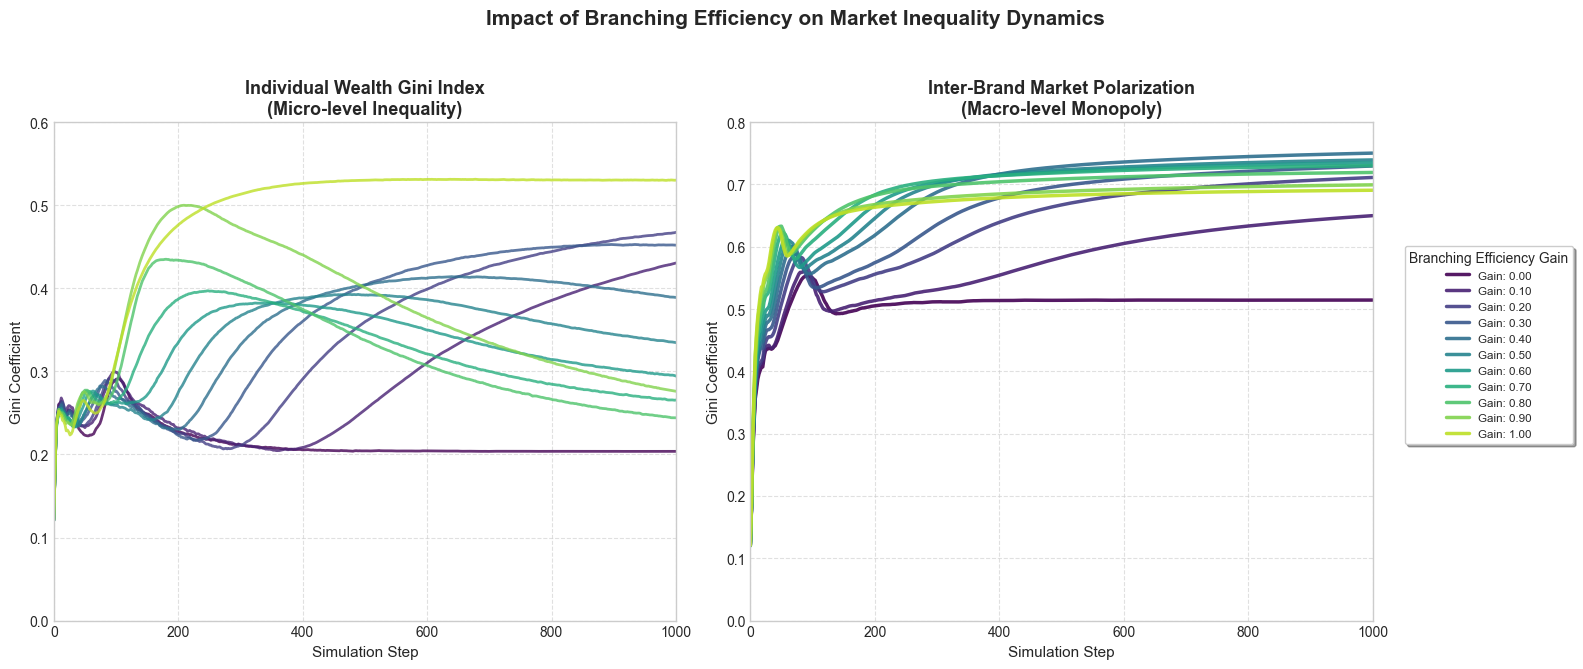

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. 设置画布：对比个人层面与品牌层面的不平等
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# 2. 识别唯一的效率增益梯度 (Efficiency Gain)
unique_gains = sorted(experiment_B_efficiency_gain_summary['efficiency-gain'].unique())

# 3. 颜色映射：使用 viridis 或 plasma 表现效率由低到高的变化
colors = plt.cm.viridis(np.linspace(0, 0.9, len(unique_gains)))

# 4. 遍历每个效率组进行绘图
for i, gain_val in enumerate(unique_gains):
    # 筛选数据
    subset = experiment_B_efficiency_gain_summary[
        experiment_B_efficiency_gain_summary['efficiency-gain'] == gain_val
    ].sort_values('step')
    
    if subset.empty:
        continue

    x = subset['step'].values
    y_gini = subset['gini-index_mean'].values
    y_brand_gini = subset['brand-gini-index_mean'].values
    
    # 平滑曲线处理
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        
        # 个体基尼系数平滑
        spl_gini = make_interp_spline(x, y_gini, k=3)
        y_gini_smooth = spl_gini(x_smooth)
        
        # 品牌基尼系数平滑
        spl_brand = make_interp_spline(x, y_brand_gini, k=3)
        y_brand_gini_smooth = spl_brand(x_smooth)
        
        ax1.plot(x_smooth, y_gini_smooth, color=colors[i], linewidth=2, alpha=0.8)
        ax2.plot(x_smooth, y_brand_gini_smooth, label=f'Gain: {gain_val:.2f}', color=colors[i], linewidth=2.5, alpha=0.9)
    else:
        ax1.plot(x, y_gini, color=colors[i], linewidth=2)
        ax2.plot(x, y_brand_gini, label=f'Gain: {gain_val:.2f}', color=colors[i], linewidth=2.5)

# 5. 格式化左图：个体层面的财富差距
ax1.set_title('Individual Wealth Gini Index\n(Micro-level Inequality)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Simulation Step', fontsize=11)
ax1.set_ylabel('Gini Coefficient', fontsize=11)
ax1.set_ylim(0, 0.6) 
ax1.grid(True, linestyle='--', alpha=0.6)

# 6. 格式化右图：品牌/种族层面的市场极化
# 这里的 Inter-Brand Gini 反映了强势企业对市场的垄断程度
ax2.set_title('Inter-Brand Market Polarization\n(Macro-level Monopoly)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Simulation Step', fontsize=11)
ax2.set_ylabel('Gini Coefficient', fontsize=11)
ax2.set_ylim(0, 0.8) 
ax2.set_xlim(0, 1000) 
ax2.grid(True, linestyle='--', alpha=0.6)

# 7. 创建共享图例
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title="Branching Efficiency Gain", loc='center right', 
           bbox_to_anchor=(0.99, 0.5), fontsize='small', frameon=True, shadow=True)

# 8. 总标题与布局微调
fig.suptitle('Impact of Branching Efficiency on Market Inequality Dynamics', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 0.88, 0.95]) 

plt.show()

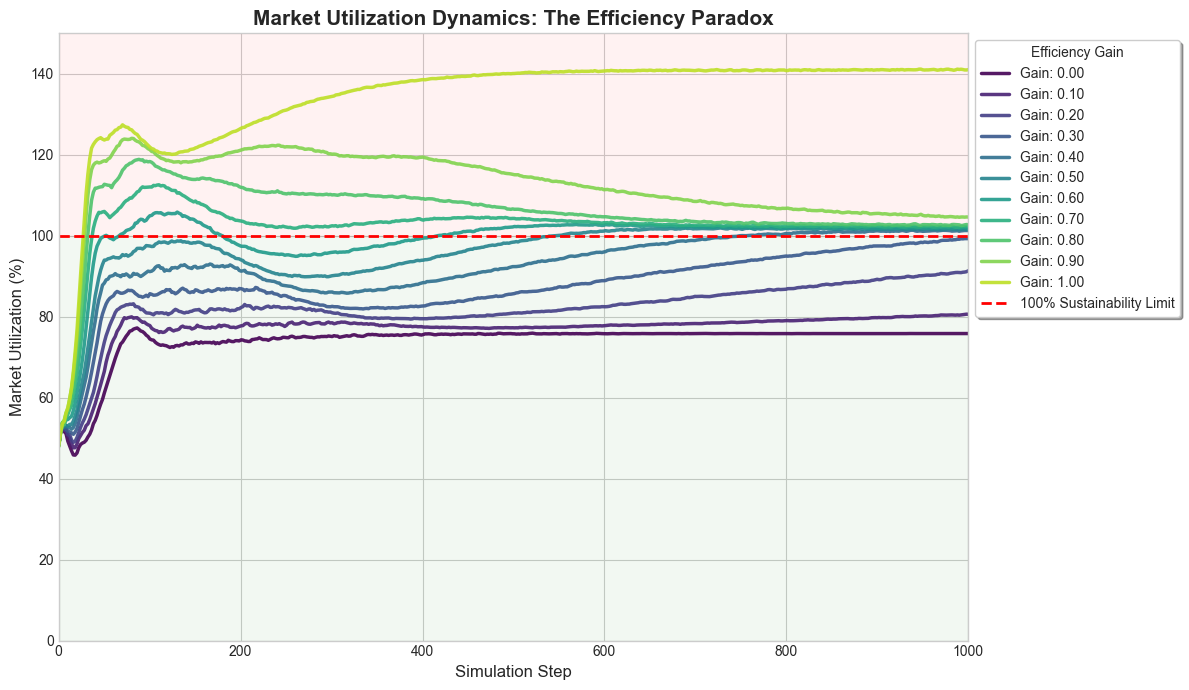

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. 设置画布
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. 获取效率增益的所有梯度
unique_gains = sorted(experiment_B_efficiency_gain_summary['efficiency-gain'].unique())
colors = plt.cm.viridis(np.linspace(0, 0.9, len(unique_gains)))

# 3. 循环绘制每一组效率下的利用率曲线
for i, gain_val in enumerate(unique_gains):
    subset = experiment_B_efficiency_gain_summary[
        experiment_B_efficiency_gain_summary['efficiency-gain'] == gain_val
    ].sort_values('step')
    
    if subset.empty:
        continue

    x = subset['step'].values
    y_util = subset['market-utilization_mean'].values
    
    # 平滑处理
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        spl = make_interp_spline(x, y_util, k=3)
        y_smooth = spl(x_smooth)
        
        # 绘图：利用率随时间的变化
        plt.plot(x_smooth, y_smooth, label=f'Gain: {gain_val:.2f}', color=colors[i], linewidth=2.5, alpha=0.9)
    else:
        plt.plot(x, y_util, label=f'Gain: {gain_val:.2f}', color=colors[i], linewidth=2.5)

# 4. 添加 100% 警戒线 (Critical Threshold)
# 超过这条线代表市场进入“公地悲剧”式的超负荷状态
plt.axhline(y=100, color='red', linestyle='--', linewidth=2, label='100% Sustainability Limit')

# 5. 图表修饰
plt.title('Market Utilization Dynamics: The Efficiency Paradox', fontsize=15, fontweight='bold')
plt.xlabel('Simulation Step', fontsize=12)
plt.ylabel('Market Utilization (%)', fontsize=12)
plt.ylim(0, 150)  # 纵轴设高一点，以观察超过 100% 的“泡沫”现象
plt.xlim(0, 1000)

# 设置图例
plt.legend(title="Efficiency Gain", loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)

# 6. 添加背景区域标注（可选，增加专业感）
plt.fill_between([0, 1000], 0, 100, color='green', alpha=0.05, label='Sustainable Zone')
plt.fill_between([0, 1000], 100, 150, color='red', alpha=0.05, label='Overshoot Zone')

plt.tight_layout()
plt.show()